# Comparação de Modelos de Sobrevivência com Parâmetros Fixos e Avaliação em Conjunto de Teste

Este notebook compara modelos estatísticos e modelos de Machine Learning para predição de sobrevida de pacientes com câncer colorretal. O fluxo usa os artefatos gerados pelo pré-processamento, aplica codificação coerente com a natureza das variáveis, treina modelos com parâmetros fixos e avalia o desempenho no conjunto de teste.

A comparação principal aqui é empírica e interna ao notebook de Machine Learning. O modelo Cox estatístico completo, com discussão inferencial própria, permanece tratado no notebook `Cox.ipynb`.


## Fase 1 — Carregamento dos dados

Os arquivos de treino e teste já foram definidos na etapa de pré-processamento. Nesta versão, o conjunto de treino é usado para ajustar encoders e modelos, enquanto o conjunto de teste é reservado para avaliação final. Como não há escolha de hiperparâmetros baseada em desempenho, não é usada validação cruzada neste notebook.


In [1]:
import json
import re
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display
from lifelines import KaplanMeierFitter, LogLogisticAFTFitter, LogNormalAFTFitter, WeibullAFTFitter
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import (
    brier_score,
    concordance_index_censored,
    concordance_index_ipcw,
    cumulative_dynamic_auc,
    integrated_brier_score,
)
from sksurv.util import Surv

warnings.filterwarnings("ignore")
set_config(display="text")

RANDOM_STATE = 19
CLINICAL_TIMES = np.array([12.0, 36.0, 60.0], dtype=float)

BASE_DIR = Path("../data/processed")
RESULTS_DIR = Path("results")
METRICS_DIR = RESULTS_DIR / "metrics"
PREDS_DIR = RESULTS_DIR / "predictions"
PARAMS_DIR = RESULTS_DIR / "params"
FIGURES_DIR = RESULTS_DIR / "figures"
ARTIFACTS_DIR = RESULTS_DIR / "artifacts"
FITTED_MODELS_DIR = ARTIFACTS_DIR / "fitted_models"

for directory in [METRICS_DIR, PREDS_DIR, PARAMS_DIR, FIGURES_DIR, ARTIFACTS_DIR, FITTED_MODELS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Bibliotecas carregadas e diretórios preparados.")


Bibliotecas carregadas e diretórios preparados.


In [2]:
metadata_path = BASE_DIR / "dataset_metadata_2025.json"
train_path = BASE_DIR / "train_data_2025.csv"
test_path = BASE_DIR / "test_data_2025.csv"

with open(metadata_path, "r", encoding="utf-8") as file:
    metadata = json.load(file)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

predictor_cols = metadata["predictor_columns"]
target_cols = metadata["target_columns"]

X_train = df_train[predictor_cols].copy()
X_test = df_test[predictor_cols].copy()

y_train_time = df_train["time"].astype(float).to_numpy()
y_test_time = df_test["time"].astype(float).to_numpy()
y_train_event = df_train["event"].astype(bool).to_numpy()
y_test_event = df_test["event"].astype(bool).to_numpy()

y_train_surv = Surv.from_arrays(event=y_train_event, time=y_train_time)
y_test_surv = Surv.from_arrays(event=y_test_event, time=y_test_time)

print(f"Treino: {df_train.shape[0]} pacientes, {int(y_train_event.sum())} eventos")
print(f"Teste: {df_test.shape[0]} pacientes, {int(y_test_event.sum())} eventos")
print(f"Preditores: {len(predictor_cols)}")
display(df_train.head())


Treino: 26131 pacientes, 14512 eventos
Teste: 6533 pacientes, 3628 eventos
Preditores: 15


,INSTITU,ESCOLARI,IDADE,SEXO,CATEATEND,DIAGPREV,TOPO,ECGRUP,ANODIAG,HABILIT,nDRS,CONSDIAG_CAT,TRATCONS_CAT,DIAGTRAT_CAT,MORFO_CAT,time,event
0,21636,2,67,1,2,2,C209,III,2016,1,6,3,0,2,Adenocarcinoma,61,0
1,20621,9,29,2,2,2,C186,III,2019,2,3,3,0,1,Adenocarcinoma,61,0
2,20737,2,64,1,9,2,C180,IV,2004,1,15,3,3,3,Adenocarcinoma,2,1
3,20737,2,63,2,2,2,C209,IV,2012,1,5,3,3,3,Adenocarcinoma,1,1
4,16624,3,53,1,2,1,C209,III,2013,1,1,0,2,2,Adenocarcinoma,6,1


## Fase 2 — Definição conceitual das variáveis

As variáveis foram separadas antes da codificação para evitar tratar códigos categóricos como medidas contínuas. Apenas `IDADE` e `ANODIAG` recebem padronização. Variáveis ordinais reais recebem codificação ordinal, variáveis nominais recebem one-hot encoding e a variável binária `SEXO` é convertida para 0/1. Todos os transformadores são ajustados apenas no treino e depois aplicados ao teste, evitando vazamento de informação.


In [3]:
continuous_cols = ["IDADE", "ANODIAG"]
ordinal_cols = ["ECGRUP", "ESCOLARI"]
binary_cols = ["SEXO"]
nominal_cols = [
    "INSTITU",
    "CATEATEND",
    "DIAGPREV",
    "HABILIT",
    "nDRS",
    "CONSDIAG_CAT",
    "TRATCONS_CAT",
    "DIAGTRAT_CAT",
    "TOPO",
    "MORFO_CAT",
]

schema_cols = continuous_cols + ordinal_cols + binary_cols + nominal_cols
missing_cols = sorted(set(schema_cols) - set(predictor_cols))
extra_predictors = sorted(set(predictor_cols) - set(schema_cols))

if missing_cols:
    raise ValueError(f"Colunas definidas no schema não encontradas nos preditores: {missing_cols}")
if extra_predictors:
    raise ValueError(f"Preditores sem classificação conceitual no schema: {extra_predictors}")

variable_schema = {
    "continuous_cols": continuous_cols,
    "ordinal_cols": ordinal_cols,
    "binary_cols": binary_cols,
    "nominal_cols": nominal_cols,
    "target_cols": target_cols,
}

print("Schema conceitual das variáveis:")
for group_name, columns in variable_schema.items():
    print(f"- {group_name}: {columns}")


Schema conceitual das variáveis:
- continuous_cols: ['IDADE', 'ANODIAG']
- ordinal_cols: ['ECGRUP', 'ESCOLARI']
- binary_cols: ['SEXO']
- nominal_cols: ['INSTITU', 'CATEATEND', 'DIAGPREV', 'HABILIT', 'nDRS', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT', 'TOPO', 'MORFO_CAT']
- target_cols: ['time', 'event']


## Fase 3 — Pré-processamento

O pré-processador é único e reproduzível. O one-hot encoding usa `drop="first"` para reduzir colinearidade, o que é importante para modelos lineares como Cox e para os modelos paramétricos do `lifelines`. Essa escolha é uma regra fixa de codificação.


In [4]:
class BinaryZeroOneEncoder(BaseEstimator, TransformerMixin):
    """Codifica variáveis binárias observadas no treino como 0/1."""

    def __init__(self, unknown_value=-1.0):
        self.unknown_value = unknown_value

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.feature_names_in_ = np.array(X_df.columns, dtype=object)
        self.category_maps_ = {}
        for column in X_df.columns:
            values = sorted(pd.Series(X_df[column]).dropna().unique().tolist())
            if len(values) != 2:
                raise ValueError(f"A coluna {column} deveria ter exatamente 2 categorias no treino; encontrou {values}.")
            self.category_maps_[column] = {values[0]: 0.0, values[1]: 1.0}
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        transformed = pd.DataFrame(index=X_df.index)
        for column in self.feature_names_in_:
            transformed[column] = X_df[column].map(self.category_maps_[column]).fillna(self.unknown_value)
        return transformed.to_numpy(dtype=float)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_ if input_features is None else np.asarray(input_features, dtype=object)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)


def sanitize_feature_names(names):
    cleaned, used = [], {}
    for name in names:
        clean = re.sub(r"[^0-9A-Za-z_]+", "_", str(name)).strip("_")
        clean = re.sub(r"_+", "_", clean) or "feature"
        count = used.get(clean, 0)
        used[clean] = count + 1
        cleaned.append(f"{clean}_{count}" if count else clean)
    return cleaned


ordinal_categories = [
    ["I", "II", "III", "IV"],
    sorted(pd.Series(X_train["ESCOLARI"]).dropna().unique().tolist()),
]

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), continuous_cols),
        (
            "ordinal",
            OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1),
            ordinal_cols,
        ),
        ("binary", BinaryZeroOneEncoder(), binary_cols),
        ("nominal", make_one_hot_encoder(), nominal_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_encoded_array = preprocessor.fit_transform(X_train)
X_test_encoded_array = preprocessor.transform(X_test)
feature_names_encoded = sanitize_feature_names(preprocessor.get_feature_names_out().tolist())

X_train_encoded = pd.DataFrame(X_train_encoded_array, columns=feature_names_encoded, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded_array, columns=feature_names_encoded, index=X_test.index)

print(f"Matriz codificada de treino: {X_train_encoded.shape}")
print(f"Matriz codificada de teste: {X_test_encoded.shape}")
display(X_train_encoded.head())


Matriz codificada de treino: (26131, 109)
Matriz codificada de teste: (6533, 109)


,IDADE,ANODIAG,ECGRUP,ESCOLARI,SEXO,INSTITU_10,INSTITU_12,INSTITU_15,INSTITU_8672,INSTITU_9326,...,TOPO_C185,TOPO_C186,TOPO_C187,TOPO_C188,TOPO_C189,TOPO_C199,TOPO_C209,MORFO_CAT_Anel_de_sinete,MORFO_CAT_Indiferenciado,MORFO_CAT_Mucinoso
0,0.402490,0.861481,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-2.508175,1.420417,2.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.172700,-1.374265,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.096104,0.116232,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-0.669861,0.302544,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Fase 4 — Definição dos modelos

Os modelos são treinados com parâmetros fixos e documentados. Não há etapa de seleção automática de parâmetros nesta versão. Por isso, o hold-out treino/teste é a validação principal.

Modelos que produzem apenas escore de risco são avaliados por discriminação. Modelos que produzem função de sobrevivência individual também recebem Brier Score e IBS. Quando uma saída não existe para um modelo, a respectiva métrica ou predição fica como `NaN`.


In [5]:
def ensure_dataframe(X, feature_names=None):
    if isinstance(X, pd.DataFrame):
        return X.copy()
    X_array = np.asarray(X)
    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(X_array.shape[1])]
    return pd.DataFrame(X_array, columns=list(feature_names))


def safe_1d(values):
    return np.asarray(values, dtype=float).reshape(-1)


def xgb_gain_importance(booster, feature_names):
    importance_map = booster.get_score(importance_type="gain")
    return np.array([importance_map.get(name, 0.0) for name in feature_names], dtype=float)


class XGBoostCoxWrapper(BaseEstimator):
    """Adaptador do objetivo survival:cox do XGBoost."""

    def __init__(self, params=None, num_boost_round=150):
        self.params = {} if params is None else params
        self.num_boost_round = num_boost_round

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()
        signed_time = np.where(y["event"], y["time"], -y["time"]).astype(float)
        dtrain = xgb.DMatrix(X_df, label=signed_time, feature_names=self.feature_names_in_.tolist())
        params = {
            "objective": "survival:cox",
            "eval_metric": "cox-nloglik",
            "learning_rate": 0.05,
            "max_depth": 4,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "min_child_weight": 1.0,
            "tree_method": "hist",
            "verbosity": 0,
            "seed": RANDOM_STATE,
        }
        params.update(self.params)
        self.model_ = xgb.train(params=params, dtrain=dtrain, num_boost_round=self.num_boost_round, verbose_eval=False)
        self.feature_importances_ = xgb_gain_importance(self.model_, self.feature_names_in_.tolist())
        self.training_params_ = {**params, "num_boost_round": self.num_boost_round}
        return self

    def predict(self, X):
        X_df = ensure_dataframe(X, self.feature_names_in_)
        dtest = xgb.DMatrix(X_df, feature_names=self.feature_names_in_.tolist())
        return safe_1d(self.model_.predict(dtest))


class XGBoostAFTWrapper(BaseEstimator):
    """Adaptador do objetivo survival:aft do XGBoost.

    Decisão de escala: `Booster.predict()` é tratado como tempo previsto na escala original
    dos rótulos em meses. Portanto, não aplicamos `np.exp()` na saída.
    """

    def __init__(self, params=None, num_boost_round=150, prediction_scale="time"):
        self.params = {} if params is None else params
        self.num_boost_round = num_boost_round
        self.prediction_scale = prediction_scale

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()
        lower_bound = np.asarray(y["time"], dtype=float)
        upper_bound = lower_bound.copy()
        upper_bound[~y["event"]] = np.inf
        dtrain = xgb.DMatrix(X_df, feature_names=self.feature_names_in_.tolist())
        dtrain.set_float_info("label_lower_bound", lower_bound)
        dtrain.set_float_info("label_upper_bound", upper_bound)
        params = {
            "objective": "survival:aft",
            "eval_metric": "aft-nloglik",
            "aft_loss_distribution": "normal",
            "aft_loss_distribution_scale": 1.0,
            "learning_rate": 0.05,
            "max_depth": 4,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "tree_method": "hist",
            "verbosity": 0,
            "seed": RANDOM_STATE,
        }
        params.update(self.params)
        self.model_ = xgb.train(params=params, dtrain=dtrain, num_boost_round=self.num_boost_round, verbose_eval=False)
        self.feature_importances_ = xgb_gain_importance(self.model_, self.feature_names_in_.tolist())
        self.training_params_ = {**params, "num_boost_round": self.num_boost_round, "prediction_scale": self.prediction_scale}
        return self

    def predict_time(self, X):
        X_df = ensure_dataframe(X, self.feature_names_in_)
        dtest = xgb.DMatrix(X_df, feature_names=self.feature_names_in_.tolist())
        raw_prediction = safe_1d(self.model_.predict(dtest))
        if self.prediction_scale == "log_time":
            predicted_time = np.exp(np.clip(raw_prediction, -20, 20))
        elif self.prediction_scale == "time":
            predicted_time = raw_prediction
        else:
            raise ValueError("prediction_scale deve ser 'time' ou 'log_time'.")
        return np.clip(predicted_time, 1e-6, None)

    def predict(self, X):
        return -self.predict_time(X)


In [6]:
def prepare_breslow_targets(times, events):
    order = np.argsort(-times, kind="mergesort")
    times_sorted = np.asarray(times, dtype=float)[order]
    events_sorted = np.asarray(events, dtype=float)[order]
    _, starts = np.unique(times_sorted, return_index=True)
    starts = np.sort(starts)
    ends = np.r_[starts[1:] - 1, len(times_sorted) - 1]
    group_event_counts = np.array([events_sorted[start:end + 1].sum() for start, end in zip(starts, ends)], dtype=float)
    return order, events_sorted, starts, ends, group_event_counts


def cox_negative_gradient_hessian(preds, signed_time_labels):
    signed_time_labels = np.asarray(signed_time_labels, dtype=float)
    times = np.abs(signed_time_labels)
    events = (signed_time_labels > 0).astype(float)
    order, events_sorted, _, ends, group_event_counts = prepare_breslow_targets(times, events)
    preds_sorted = np.asarray(preds, dtype=float)[order]
    shifted_preds = preds_sorted - np.max(preds_sorted)
    exp_preds = np.exp(shifted_preds)
    cumulative_risk = np.cumsum(exp_preds)
    denominators = np.clip(cumulative_risk[ends], 1e-12, None)
    contribution = np.zeros_like(preds_sorted)
    contribution_sq = np.zeros_like(preds_sorted)
    contribution[ends] = group_event_counts / denominators
    contribution_sq[ends] = group_event_counts / np.square(denominators)
    suffix_sum = np.cumsum(contribution[::-1])[::-1]
    suffix_sum_sq = np.cumsum(contribution_sq[::-1])[::-1]
    grad_sorted = -events_sorted + exp_preds * suffix_sum
    hess_sorted = np.clip(exp_preds * suffix_sum - np.square(exp_preds) * suffix_sum_sq, 1e-8, None)
    grad = np.empty_like(grad_sorted)
    hess = np.empty_like(hess_sorted)
    grad[order] = grad_sorted
    hess[order] = hess_sorted
    return grad, hess


def cox_negative_partial_log_likelihood(preds, signed_time_labels):
    signed_time_labels = np.asarray(signed_time_labels, dtype=float)
    times = np.abs(signed_time_labels)
    events = (signed_time_labels > 0).astype(float)
    order, events_sorted, starts, ends, group_event_counts = prepare_breslow_targets(times, events)
    preds_sorted = np.asarray(preds, dtype=float)[order]
    max_pred = np.max(preds_sorted)
    shifted_preds = preds_sorted - max_pred
    exp_preds = np.exp(shifted_preds)
    cumulative_risk = np.cumsum(exp_preds)
    denominators = np.clip(cumulative_risk[ends], 1e-12, None)
    log_denominators = np.log(denominators) + max_pred
    event_prediction_sum = np.array([
        preds_sorted[start:end + 1][events_sorted[start:end + 1].astype(bool)].sum()
        for start, end in zip(starts, ends)
    ])
    return float(np.sum(group_event_counts * log_denominators - event_prediction_sum))


class LightGBMCoxWrapper(BaseEstimator):
    """LightGBM com objetivo Cox customizado e empates por Breslow."""

    def __init__(self, params=None, num_boost_round=150):
        self.params = {} if params is None else params
        self.num_boost_round = num_boost_round

    def _objective(self, preds, dataset):
        return cox_negative_gradient_hessian(preds, dataset.get_label())

    def _metric(self, preds, dataset):
        return "cox_neg_partial_loglik", cox_negative_partial_log_likelihood(preds, dataset.get_label()), False

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()
        signed_time = np.where(y["event"], y["time"], -y["time"]).astype(float)
        train_set = lgb.Dataset(X_df, label=signed_time, feature_name=self.feature_names_in_.tolist(), free_raw_data=False)
        params = {
            "objective": self._objective,
            "metric": "None",
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 5,
            "min_data_in_leaf": 20,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l2": 1.0,
            "verbosity": -1,
            "seed": RANDOM_STATE,
            "num_threads": 1,
        }
        params.update(self.params)
        self.model_ = lgb.train(params=params, train_set=train_set, num_boost_round=self.num_boost_round, feval=self._metric)
        self.feature_importances_ = self.model_.feature_importance(importance_type="gain")
        self.training_params_ = {
            **{key: value for key, value in params.items() if key != "objective"},
            "objective": "custom_cox_partial_loglik",
            "tie_handling": "breslow",
            "num_boost_round": self.num_boost_round,
        }
        return self

    def predict(self, X):
        X_df = ensure_dataframe(X, self.feature_names_in_)
        return safe_1d(self.model_.predict(X_df))


class LightGBMObservedTimeWrapper(BaseEstimator):
    """Baseline LightGBM para tempo observado; não modela censura diretamente."""

    def __init__(self, params=None):
        self.params = {} if params is None else params

    def fit(self, X, y):
        X_df = ensure_dataframe(X)
        self.feature_names_in_ = X_df.columns.to_numpy()
        params = {
            "objective": "regression",
            "n_estimators": 150,
            "learning_rate": 0.05,
            "num_leaves": 31,
            "max_depth": 5,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "reg_lambda": 1.0,
            "random_state": RANDOM_STATE,
            "n_jobs": 1,
            "verbosity": -1,
        }
        params.update(self.params)
        self.model_ = lgb.LGBMRegressor(**params)
        self.model_.fit(X_df, y["time"].astype(float))
        self.training_params_ = params
        self.feature_importances_ = self.model_.feature_importances_
        return self

    def predict_time(self, X):
        X_df = ensure_dataframe(X, self.feature_names_in_)
        return np.clip(safe_1d(self.model_.predict(X_df)), 1e-6, None)

    def predict(self, X):
        return -self.predict_time(X)


class LifelinesAFTWrapper(BaseEstimator):
    """Adaptador para modelos AFT paramétricos do lifelines."""

    def __init__(self, fitter_class, penalizer=0.01, l1_ratio=0.0, label="AFT"):
        self.fitter_class = fitter_class
        self.penalizer = penalizer
        self.l1_ratio = l1_ratio
        self.label = label

    def fit(self, X, y):
        X_df = ensure_dataframe(X).copy()
        self.feature_names_in_ = X_df.columns.to_numpy()
        fit_df = X_df.copy()
        fit_df["time"] = y["time"].astype(float)
        fit_df["event"] = y["event"].astype(int)
        self.model_ = self.fitter_class(penalizer=self.penalizer, l1_ratio=self.l1_ratio)
        self.model_.fit(fit_df, duration_col="time", event_col="event")
        self.training_params_ = {"fitter": self.fitter_class.__name__, "penalizer": self.penalizer, "l1_ratio": self.l1_ratio}
        return self

    def predict_time(self, X):
        X_df = ensure_dataframe(X, self.feature_names_in_)
        return np.clip(safe_1d(self.model_.predict_median(X_df)), 1e-6, None)

    def predict(self, X):
        return -self.predict_time(X)

    def predict_survival_matrix(self, X, times):
        X_df = ensure_dataframe(X, self.feature_names_in_)
        survival_df = self.model_.predict_survival_function(X_df, times=np.asarray(times, dtype=float))
        return survival_df.T.to_numpy(dtype=float)


In [7]:
fixed_model_parameters = {
    "Cox_PH": {"alpha": 0.01, "ties": "breslow", "role": "baseline interno; Cox completo em Cox.ipynb"},
    "Weibull_AFT": {"fitter": "WeibullAFTFitter", "penalizer": 0.01, "l1_ratio": 0.0},
    "LogNormal_AFT": {"fitter": "LogNormalAFTFitter", "penalizer": 0.01, "l1_ratio": 0.0},
    "LogLogistic_AFT": {"fitter": "LogLogisticAFTFitter", "penalizer": 0.01, "l1_ratio": 0.0},
    "Random_Survival_Forest": {"n_estimators": 200, "min_samples_split": 10, "min_samples_leaf": 5, "max_features": "sqrt", "random_state": RANDOM_STATE, "n_jobs": 1},
    "Gradient_Boosting_Survival": {"learning_rate": 0.05, "n_estimators": 150, "max_depth": 3, "random_state": RANDOM_STATE},
    "XGBoost_Cox": {"objective": "survival:cox", "label_encoding": "tempo positivo para evento e tempo negativo para censura à direita", "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0, "num_boost_round": 150},
    "XGBoost_AFT": {"objective": "survival:aft", "label_encoding": "lower/upper bounds; censura à direita com upper_bound=+inf", "aft_loss_distribution": "normal", "aft_loss_distribution_scale": 1.0, "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0, "num_boost_round": 150, "prediction_scale_decision": "Booster.predict() tratado como tempo em meses; np.exp() não é aplicado."},
    "LightGBM": {"objective": "regression", "n_estimators": 150, "learning_rate": 0.05, "num_leaves": 31, "max_depth": 5, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 1.0, "observacao": "baseline de tempo observado; não modela censura diretamente"},
    "LightGBM_Cox": {"objective": "custom_cox_partial_loglik", "tie_handling": "breslow", "label_encoding": "tempo positivo para evento e tempo negativo para censura à direita", "learning_rate": 0.05, "num_leaves": 31, "max_depth": 5, "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 1, "lambda_l2": 1.0, "num_boost_round": 150},
}

model_registry = [
    {"model_name": "Cox_PH", "family": "survival_function", "group": "estatístico semiparamétrico", "factory": lambda: CoxPHSurvivalAnalysis(alpha=0.01, ties="breslow"), "supports_survival_function": True, "supports_predicted_time": False},
    {"model_name": "Weibull_AFT", "family": "parametric_aft", "group": "estatístico paramétrico", "factory": lambda: LifelinesAFTWrapper(WeibullAFTFitter, penalizer=0.01, label="Weibull_AFT"), "supports_survival_function": True, "supports_predicted_time": True},
    {"model_name": "LogNormal_AFT", "family": "parametric_aft", "group": "estatístico paramétrico", "factory": lambda: LifelinesAFTWrapper(LogNormalAFTFitter, penalizer=0.01, label="LogNormal_AFT"), "supports_survival_function": True, "supports_predicted_time": True},
    {"model_name": "LogLogistic_AFT", "family": "parametric_aft", "group": "estatístico paramétrico", "factory": lambda: LifelinesAFTWrapper(LogLogisticAFTFitter, penalizer=0.01, label="LogLogistic_AFT"), "supports_survival_function": True, "supports_predicted_time": True},
    {"model_name": "Random_Survival_Forest", "family": "survival_function", "group": "machine learning", "factory": lambda: RandomSurvivalForest(**fixed_model_parameters["Random_Survival_Forest"]), "supports_survival_function": True, "supports_predicted_time": False},
    {"model_name": "Gradient_Boosting_Survival", "family": "survival_function", "group": "machine learning", "factory": lambda: GradientBoostingSurvivalAnalysis(**fixed_model_parameters["Gradient_Boosting_Survival"]), "supports_survival_function": True, "supports_predicted_time": False},
    {"model_name": "XGBoost_Cox", "family": "risk_score", "group": "machine learning", "factory": lambda: XGBoostCoxWrapper(params={key: fixed_model_parameters["XGBoost_Cox"][key] for key in ["learning_rate", "max_depth", "subsample", "colsample_bytree", "reg_lambda"]}, num_boost_round=fixed_model_parameters["XGBoost_Cox"]["num_boost_round"]), "supports_survival_function": False, "supports_predicted_time": False},
    {"model_name": "XGBoost_AFT", "family": "predicted_time", "group": "machine learning", "factory": lambda: XGBoostAFTWrapper(params={key: fixed_model_parameters["XGBoost_AFT"][key] for key in ["learning_rate", "max_depth", "subsample", "colsample_bytree", "reg_lambda", "aft_loss_distribution", "aft_loss_distribution_scale"]}, num_boost_round=fixed_model_parameters["XGBoost_AFT"]["num_boost_round"], prediction_scale="time"), "supports_survival_function": False, "supports_predicted_time": True},
    {"model_name": "LightGBM", "family": "predicted_time", "group": "machine learning", "factory": lambda: LightGBMObservedTimeWrapper(), "supports_survival_function": False, "supports_predicted_time": True},
    {"model_name": "LightGBM_Cox", "family": "risk_score", "group": "machine learning", "factory": lambda: LightGBMCoxWrapper(params={key: fixed_model_parameters["LightGBM_Cox"][key] for key in ["learning_rate", "num_leaves", "max_depth", "feature_fraction", "bagging_fraction", "bagging_freq", "lambda_l2"]}, num_boost_round=fixed_model_parameters["LightGBM_Cox"]["num_boost_round"]), "supports_survival_function": False, "supports_predicted_time": False},
]

print("Modelos definidos, em ordem de execução:")
for entry in model_registry:
    print(f"- {entry['model_name']} ({entry['group']}; {entry['family']})")


Modelos definidos, em ordem de execução:
- Cox_PH (estatístico semiparamétrico; survival_function)
- Weibull_AFT (estatístico paramétrico; parametric_aft)
- LogNormal_AFT (estatístico paramétrico; parametric_aft)
- LogLogistic_AFT (estatístico paramétrico; parametric_aft)
- Random_Survival_Forest (machine learning; survival_function)
- Gradient_Boosting_Survival (machine learning; survival_function)
- XGBoost_Cox (machine learning; risk_score)
- XGBoost_AFT (machine learning; predicted_time)
- LightGBM (machine learning; predicted_time)
- LightGBM_Cox (machine learning; risk_score)


## Fase 5 — Treinamento com parâmetros fixos

Todos os modelos abaixo são ajustados uma única vez no conjunto de treino. O teste não participa de nenhum ajuste, seleção ou decisão de parâmetros. O Cox incluído aqui é um baseline interno treinado na mesma matriz codificada dos modelos de ML; a análise estatística final de Cox deve ser lida no notebook `Cox.ipynb`.


In [8]:
fitted_models = {}
fitted_params_summary = {}
training_failures = {}

print("Treinamento dos modelos com parâmetros fixos")
print("=" * 72)

for entry in model_registry:
    model_name = entry["model_name"]
    print(f"\n{model_name}")
    estimator = entry["factory"]()
    try:
        estimator.fit(X_train_encoded, y_train_surv)
        fitted_models[model_name] = {**entry, "estimator": estimator}
        fitted_params_summary[model_name] = getattr(estimator, "training_params_", fixed_model_parameters.get(model_name, {}))
        print("  ajustado com sucesso")
    except Exception as exc:
        training_failures[model_name] = repr(exc)
        print(f"  falhou: {exc}")

if training_failures:
    print("\nModelos com falha de ajuste:")
    for model_name, message in training_failures.items():
        print(f"- {model_name}: {message}")

if not fitted_models:
    raise RuntimeError("Nenhum modelo foi ajustado com sucesso.")


Treinamento dos modelos com parâmetros fixos

Cox_PH
  ajustado com sucesso

Weibull_AFT
  ajustado com sucesso

LogNormal_AFT
  ajustado com sucesso

LogLogistic_AFT
  ajustado com sucesso

Random_Survival_Forest
  ajustado com sucesso

Gradient_Boosting_Survival
  ajustado com sucesso

XGBoost_Cox
  ajustado com sucesso

XGBoost_AFT
  ajustado com sucesso

LightGBM
  ajustado com sucesso

LightGBM_Cox
  ajustado com sucesso


## Fase 6 — Avaliação no conjunto de teste

As métricas de discriminação avaliam a ordenação do risco: C-index, C-index IPCW e AUC temporal em 12, 36 e 60 meses. As métricas probabilísticas exigem função de sobrevivência individual: Brier Score nos mesmos horizontes e IBS. Por isso, modelos que retornam apenas risk score ou tempo previsto ficam com `NaN` em Brier/IBS.


In [9]:
def valid_metric_times(times, y_train_ref, y_test_eval):
    lower = max(float(y_train_ref["time"].min()), float(y_test_eval["time"].min()))
    upper = min(float(y_train_ref["time"].max()), float(y_test_eval["time"].max()))
    return np.asarray([time for time in times if lower < time < upper], dtype=float)


def survival_matrix_from_model(model, X, times):
    times = np.asarray(times, dtype=float)
    if hasattr(model, "predict_survival_matrix"):
        return np.asarray(model.predict_survival_matrix(X, times), dtype=float)
    if not hasattr(model, "predict_survival_function"):
        raise AttributeError("Modelo não expõe função de sobrevivência individual.")
    survival_functions = model.predict_survival_function(X)
    return np.asarray([[float(fn(time)) for time in times] for fn in survival_functions], dtype=float)


def median_time_from_survival_matrix(survival_probs, times):
    times = np.asarray(times, dtype=float)
    medians = np.full(survival_probs.shape[0], np.nan, dtype=float)
    for row_idx, row in enumerate(survival_probs):
        below = np.where(row <= 0.5)[0]
        if below.size:
            medians[row_idx] = times[below[0]]
    return medians


def predict_time_if_available(model, X, supports_predicted_time, survival_times=None):
    if supports_predicted_time and hasattr(model, "predict_time"):
        return safe_1d(model.predict_time(X))
    if survival_times is not None:
        try:
            return median_time_from_survival_matrix(survival_matrix_from_model(model, X, survival_times), survival_times)
        except Exception:
            return np.full(X.shape[0], np.nan)
    return np.full(X.shape[0], np.nan)


def compute_discrimination_metrics(risk_scores, y_train_ref, y_test_eval):
    metrics = {"C_Index": np.nan, "C_Index_IPCW": np.nan, "AUC_12m": np.nan, "AUC_36m": np.nan, "AUC_60m": np.nan, "Mean_Time_AUC": np.nan}
    try:
        metrics["C_Index"] = concordance_index_censored(y_test_eval["event"], y_test_eval["time"], risk_scores)[0]
    except Exception:
        pass
    try:
        tau = min(60.0, float(y_train_ref["time"].max()) - 1e-6)
        metrics["C_Index_IPCW"] = concordance_index_ipcw(y_train_ref, y_test_eval, risk_scores, tau=tau)[0]
    except Exception:
        pass
    auc_times = valid_metric_times(CLINICAL_TIMES, y_train_ref, y_test_eval)
    if auc_times.size:
        try:
            auc_values, mean_auc = cumulative_dynamic_auc(y_train_ref, y_test_eval, risk_scores, auc_times)
            auc_map = dict(zip(auc_times.astype(int), auc_values))
            for horizon in [12, 36, 60]:
                metrics[f"AUC_{horizon}m"] = float(auc_map.get(horizon, np.nan))
            metrics["Mean_Time_AUC"] = float(mean_auc)
        except Exception:
            pass
    return metrics


def compute_probability_metrics(model, X_test_eval, y_train_ref, y_test_eval):
    metrics = {"Brier_12m": np.nan, "Brier_36m": np.nan, "Brier_60m": np.nan, "IBS": np.nan}
    brier_times = valid_metric_times(CLINICAL_TIMES, y_train_ref, y_test_eval)
    if brier_times.size:
        try:
            survival_probs = survival_matrix_from_model(model, X_test_eval, brier_times)
            _, brier_values = brier_score(y_train_ref, y_test_eval, survival_probs, brier_times)
            brier_map = dict(zip(brier_times.astype(int), brier_values))
            for horizon in [12, 36, 60]:
                metrics[f"Brier_{horizon}m"] = float(brier_map.get(horizon, np.nan))
        except Exception:
            pass
    ibs_times = valid_metric_times(np.unique(np.r_[np.linspace(6, 60, 12), CLINICAL_TIMES]), y_train_ref, y_test_eval)
    if ibs_times.size >= 2:
        try:
            metrics["IBS"] = float(integrated_brier_score(y_train_ref, y_test_eval, survival_matrix_from_model(model, X_test_eval, ibs_times), ibs_times))
        except Exception:
            pass
    return metrics


In [10]:
metrics_records = []
prediction_frames = []

survival_times_for_prediction = valid_metric_times(np.arange(1, 61, dtype=float), y_train_surv, y_test_surv)
clinical_prediction_times = valid_metric_times(CLINICAL_TIMES, y_train_surv, y_test_surv)

print("Avaliação no conjunto de teste")
print("=" * 72)

for model_name, entry in fitted_models.items():
    model = entry["estimator"]
    print(f"\n{model_name}")
    risk_scores = safe_1d(model.predict(X_test_encoded))
    discrimination_metrics = compute_discrimination_metrics(risk_scores, y_train_surv, y_test_surv)
    probability_metrics = (
        compute_probability_metrics(model, X_test_encoded, y_train_surv, y_test_surv)
        if entry["supports_survival_function"]
        else {"Brier_12m": np.nan, "Brier_36m": np.nan, "Brier_60m": np.nan, "IBS": np.nan}
    )
    predicted_time = predict_time_if_available(
        model,
        X_test_encoded,
        supports_predicted_time=entry["supports_predicted_time"],
        survival_times=survival_times_for_prediction if entry["supports_survival_function"] else None,
    )
    survival_probability_columns = {
        "survival_probability_12m": np.full(len(X_test_encoded), np.nan),
        "survival_probability_36m": np.full(len(X_test_encoded), np.nan),
        "survival_probability_60m": np.full(len(X_test_encoded), np.nan),
    }
    if entry["supports_survival_function"] and clinical_prediction_times.size:
        try:
            clinical_survival = survival_matrix_from_model(model, X_test_encoded, clinical_prediction_times)
            for col_idx, horizon in enumerate(clinical_prediction_times.astype(int)):
                survival_probability_columns[f"survival_probability_{horizon}m"] = clinical_survival[:, col_idx]
        except Exception:
            pass

    metrics = {
        "model_name": model_name,
        "model_group": entry["group"],
        "model_family": entry["family"],
        "supports_survival_function": entry["supports_survival_function"],
        **discrimination_metrics,
        **probability_metrics,
    }
    metrics_records.append(metrics)
    prediction_frames.append(pd.DataFrame({
        "sample_index": np.arange(len(X_test_encoded)),
        "actual_time": y_test_surv["time"],
        "actual_event": y_test_surv["event"].astype(int),
        "model_name": model_name,
        "risk_score": risk_scores,
        "predicted_time": predicted_time,
        **survival_probability_columns,
    }))

    print(f"  C-index IPCW: {metrics['C_Index_IPCW']:.4f}" if pd.notna(metrics["C_Index_IPCW"]) else "  C-index IPCW: NaN")
    print(f"  Mean Time AUC: {metrics['Mean_Time_AUC']:.4f}" if pd.notna(metrics["Mean_Time_AUC"]) else "  Mean Time AUC: NaN")
    print(f"  IBS: {metrics['IBS']:.4f}" if pd.notna(metrics["IBS"]) else "  IBS: NaN")


Avaliação no conjunto de teste

Cox_PH
  C-index IPCW: 0.7263
  Mean Time AUC: 0.7830
  IBS: 0.1727

Weibull_AFT
  C-index IPCW: 0.7262
  Mean Time AUC: 0.7829
  IBS: 0.1728

LogNormal_AFT
  C-index IPCW: 0.7252
  Mean Time AUC: 0.7820
  IBS: 0.1751

LogLogistic_AFT
  C-index IPCW: 0.7269
  Mean Time AUC: 0.7839
  IBS: 0.1737

Random_Survival_Forest
  C-index IPCW: 0.7457
  Mean Time AUC: 0.8066
  IBS: 0.1646

Gradient_Boosting_Survival
  C-index IPCW: 0.7331
  Mean Time AUC: 0.7917
  IBS: 0.1697

XGBoost_Cox
  C-index IPCW: 0.7448
  Mean Time AUC: 0.8048
  IBS: NaN

XGBoost_AFT
  C-index IPCW: 0.7440
  Mean Time AUC: 0.8041
  IBS: NaN

LightGBM
  C-index IPCW: 0.7431
  Mean Time AUC: 0.8058
  IBS: NaN

LightGBM_Cox
  C-index IPCW: 0.7470
  Mean Time AUC: 0.8075
  IBS: NaN


## Validação específica do LightGBM_Cox

O `LightGBM_Cox` usa uma função objetivo customizada baseada na negative Cox partial log-likelihood com empates tratados por Breslow. Como essa função não é um objetivo nativo do LightGBM, foram adicionadas checagens específicas para validar o gradiente, a direção do escore de risco, a generalização treino-teste e a coerência clínica dos grupos de risco.


In [11]:
def finite_difference_gradient(loss_fn, preds, labels, epsilon=1e-6):
    grad_num = np.zeros_like(preds, dtype=float)
    for idx in range(len(preds)):
        preds_plus = preds.copy()
        preds_minus = preds.copy()
        preds_plus[idx] += epsilon
        preds_minus[idx] -= epsilon
        grad_num[idx] = (loss_fn(preds_plus, labels) - loss_fn(preds_minus, labels)) / (2 * epsilon)
    return grad_num


def validate_lightgbm_cox_gradient():
    labels = np.array([5.0, -5.0, 3.0, 3.0, -2.0, 7.0, -7.0, 3.0], dtype=float)
    preds = np.array([0.25, -0.35, 0.80, -0.10, 0.45, 1.10, -0.70, 0.05], dtype=float)

    loss_value = cox_negative_partial_log_likelihood(preds, labels)
    grad_analytic, hess_analytic = cox_negative_gradient_hessian(preds, labels)
    grad_numeric = finite_difference_gradient(cox_negative_partial_log_likelihood, preds, labels)
    abs_diff = np.abs(grad_analytic - grad_numeric)

    max_abs_diff = float(np.max(abs_diff))
    mean_abs_diff = float(np.mean(abs_diff))
    hessian_clipped_fraction = float(np.mean(hess_analytic <= (1e-8 + 1e-12)))
    hessian_positive_fraction = float(np.mean(hess_analytic > 0))
    validation_passed = bool(
        max_abs_diff < 1e-4
        and np.isfinite(loss_value)
        and np.isfinite(grad_analytic).all()
        and np.isfinite(hess_analytic).all()
        and hessian_positive_fraction >= 0.80
    )

    summary = pd.DataFrame([{
        "max_abs_gradient_difference": max_abs_diff,
        "mean_abs_gradient_difference": mean_abs_diff,
        "hessian_min": float(np.min(hess_analytic)),
        "hessian_median": float(np.median(hess_analytic)),
        "hessian_max": float(np.max(hess_analytic)),
        "hessian_clipped_fraction": hessian_clipped_fraction,
        "hessian_positive_fraction": hessian_positive_fraction,
        "validation_passed": validation_passed,
    }])

    detail = pd.DataFrame({
        "prediction": preds,
        "signed_time_label": labels,
        "analytic_gradient": grad_analytic,
        "numeric_gradient": grad_numeric,
        "absolute_difference": abs_diff,
        "analytic_hessian": hess_analytic,
    })
    return summary, detail


df_lightgbm_cox_objective_validation, lightgbm_cox_gradient_detail = validate_lightgbm_cox_gradient()
display(df_lightgbm_cox_objective_validation.round(8))

if not bool(df_lightgbm_cox_objective_validation.loc[0, "validation_passed"]):
    print("Atenção: o objetivo customizado do LightGBM_Cox precisa ser revisado antes de interpretar seus resultados.")

df_lightgbm_cox_objective_validation.to_csv(
    METRICS_DIR / "lightgbm_cox_objective_validation_2025.csv",
    index=False,
)


,max_abs_gradient_difference,mean_abs_gradient_difference,hessian_min,hessian_median,hessian_max,hessian_clipped_fraction,hessian_positive_fraction,validation_passed
0,0.0,0.0,1.000000e-08,0.33235,1.011916,0.125,1.0,True


In [12]:
lightgbm_cox_available = "LightGBM_Cox" in fitted_models

if lightgbm_cox_available:
    lightgbm_cox_model = fitted_models["LightGBM_Cox"]["estimator"]
    lightgbm_cox_risk_train = safe_1d(lightgbm_cox_model.predict(X_train_encoded))
    lightgbm_cox_risk_test = safe_1d(lightgbm_cox_model.predict(X_test_encoded))

    finite_train = bool(np.isfinite(lightgbm_cox_risk_train).all())
    finite_test = bool(np.isfinite(lightgbm_cox_risk_test).all())
    nonconstant_train = bool(np.std(lightgbm_cox_risk_train) > 0)
    nonconstant_test = bool(np.std(lightgbm_cox_risk_test) > 0)

    cindex_original = concordance_index_censored(
        y_test_surv["event"],
        y_test_surv["time"],
        lightgbm_cox_risk_test,
    )[0]
    cindex_inverted = concordance_index_censored(
        y_test_surv["event"],
        y_test_surv["time"],
        -lightgbm_cox_risk_test,
    )[0]

    selected_direction = "original" if cindex_original >= cindex_inverted else "inverted_documented"
    direction_check_passed = bool(
        finite_train
        and finite_test
        and nonconstant_train
        and nonconstant_test
        and cindex_original >= cindex_inverted
    )

    if selected_direction == "inverted_documented":
        lightgbm_cox_risk_score_corrected_train = -lightgbm_cox_risk_train
        lightgbm_cox_risk_score_corrected = -lightgbm_cox_risk_test
        print("Atenção: o sinal do LightGBM_Cox pode estar invertido. Revisar interpretação do risk_score.")
    else:
        lightgbm_cox_risk_score_corrected_train = lightgbm_cox_risk_train.copy()
        lightgbm_cox_risk_score_corrected = lightgbm_cox_risk_test.copy()

    df_lightgbm_cox_direction_check = pd.DataFrame([{
        "model": "LightGBM_Cox",
        "risk_train_finite": finite_train,
        "risk_test_finite": finite_test,
        "risk_train_std_positive": nonconstant_train,
        "risk_test_std_positive": nonconstant_test,
        "cindex_original_direction": float(cindex_original),
        "cindex_inverted_direction": float(cindex_inverted),
        "selected_direction": selected_direction,
        "direction_check_passed": direction_check_passed,
    }])
else:
    lightgbm_cox_risk_train = np.array([], dtype=float)
    lightgbm_cox_risk_test = np.array([], dtype=float)
    lightgbm_cox_risk_score_corrected_train = np.array([], dtype=float)
    lightgbm_cox_risk_score_corrected = np.array([], dtype=float)
    df_lightgbm_cox_direction_check = pd.DataFrame([{
        "model": "LightGBM_Cox",
        "risk_train_finite": False,
        "risk_test_finite": False,
        "risk_train_std_positive": False,
        "risk_test_std_positive": False,
        "cindex_original_direction": np.nan,
        "cindex_inverted_direction": np.nan,
        "selected_direction": "model_not_available",
        "direction_check_passed": False,
    }])

display(df_lightgbm_cox_direction_check.round(4))
df_lightgbm_cox_direction_check.to_csv(
    METRICS_DIR / "lightgbm_cox_direction_check_2025.csv",
    index=False,
)


,model,risk_train_finite,risk_test_finite,risk_train_std_positive,risk_test_std_positive,cindex_original_direction,cindex_inverted_direction,selected_direction,direction_check_passed
0,LightGBM_Cox,True,True,True,True,0.7484,0.2516,original,True


In [13]:
if lightgbm_cox_available:
    cindex_train_lgbm_cox = concordance_index_censored(
        y_train_surv["event"],
        y_train_surv["time"],
        lightgbm_cox_risk_train,
    )[0]
    cindex_test_lgbm_cox = concordance_index_censored(
        y_test_surv["event"],
        y_test_surv["time"],
        lightgbm_cox_risk_test,
    )[0]
    generalization_gap = float(cindex_train_lgbm_cox - cindex_test_lgbm_cox)
    overfitting_warning = bool(generalization_gap > 0.07)
else:
    cindex_train_lgbm_cox = np.nan
    cindex_test_lgbm_cox = np.nan
    generalization_gap = np.nan
    overfitting_warning = False

df_lightgbm_cox_generalization_check = pd.DataFrame([{
    "model": "LightGBM_Cox",
    "cindex_train": cindex_train_lgbm_cox,
    "cindex_test": cindex_test_lgbm_cox,
    "generalization_gap": generalization_gap,
    "overfitting_warning": overfitting_warning,
}])

if overfitting_warning:
    print("Atenção: o LightGBM_Cox apresenta diferença treino-teste acima de 0.07 no C-index.")

display(df_lightgbm_cox_generalization_check.round(4))
df_lightgbm_cox_generalization_check.to_csv(
    METRICS_DIR / "lightgbm_cox_generalization_check_2025.csv",
    index=False,
)


,model,cindex_train,cindex_test,generalization_gap,overfitting_warning
0,LightGBM_Cox,0.7626,0.7484,0.0141,False


In [14]:
risk_group_labels = ["Baixo risco", "Risco intermediário", "Alto risco"]

if lightgbm_cox_available and len(lightgbm_cox_risk_score_corrected) == len(y_test_surv):
    risk_group_series = pd.qcut(
        pd.Series(lightgbm_cox_risk_score_corrected).rank(method="first"),
        q=3,
        labels=risk_group_labels,
    )

    kmf = KaplanMeierFitter()
    risk_group_records = []

    for group_name in risk_group_labels:
        group_mask = risk_group_series.to_numpy() == group_name
        group_time = y_test_surv["time"][group_mask]
        group_event = y_test_surv["event"][group_mask].astype(int)
        kmf.fit(group_time, event_observed=group_event, label=group_name)

        risk_group_records.append({
            "risk_group": group_name,
            "n": int(group_mask.sum()),
            "event_rate": float(np.mean(group_event)),
            "median_observed_time": float(np.median(group_time)),
            "mean_observed_time": float(np.mean(group_time)),
            "survival_12m_km": float(kmf.predict(12.0)),
            "survival_36m_km": float(kmf.predict(36.0)),
            "survival_60m_km": float(kmf.predict(60.0)),
        })

    df_lightgbm_cox_risk_group_summary = pd.DataFrame(risk_group_records)
    event_monotonic = bool(np.all(np.diff(df_lightgbm_cox_risk_group_summary["event_rate"]) >= -1e-8))
    survival_monotonic = bool(all(
        np.all(np.diff(df_lightgbm_cox_risk_group_summary[column]) <= 1e-8)
        for column in ["survival_12m_km", "survival_36m_km", "survival_60m_km"]
    ))
    risk_group_monotonicity_passed = bool(event_monotonic and survival_monotonic)
    df_lightgbm_cox_risk_group_summary["monotonicity_check"] = risk_group_monotonicity_passed
else:
    risk_group_series = pd.Series(dtype="category")
    risk_group_monotonicity_passed = False
    df_lightgbm_cox_risk_group_summary = pd.DataFrame(columns=[
        "risk_group",
        "n",
        "event_rate",
        "median_observed_time",
        "mean_observed_time",
        "survival_12m_km",
        "survival_36m_km",
        "survival_60m_km",
        "monotonicity_check",
    ])

if not risk_group_monotonicity_passed:
    print("Atenção: a ordenação clínica dos grupos de risco do LightGBM_Cox não foi plenamente confirmada.")

display(df_lightgbm_cox_risk_group_summary.round(4))
df_lightgbm_cox_risk_group_summary.to_csv(
    METRICS_DIR / "lightgbm_cox_risk_group_summary_2025.csv",
    index=False,
)


,risk_group,n,event_rate,median_observed_time,mean_observed_time,survival_12m_km,survival_36m_km,survival_60m_km,monotonicity_check
0,Baixo risco,2178,0.2663,61.0,49.4380,0.9353,0.8107,0.7229,True
1,Risco intermediário,2177,0.5122,45.0,39.4171,0.8265,0.6047,0.4663,True
2,Alto risco,2178,0.8875,12.0,18.6644,0.5068,0.1698,0.0913,True


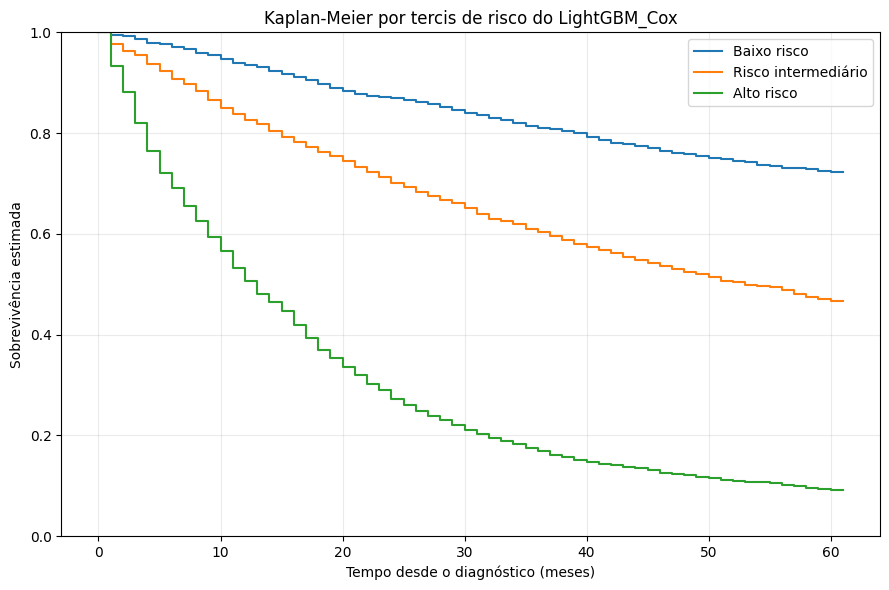

In [15]:
if lightgbm_cox_available and not df_lightgbm_cox_risk_group_summary.empty:
    fig, ax = plt.subplots(figsize=(9, 6))
    kmf = KaplanMeierFitter()

    for group_name in risk_group_labels:
        group_mask = risk_group_series.to_numpy() == group_name
        kmf.fit(
            y_test_surv["time"][group_mask],
            event_observed=y_test_surv["event"][group_mask].astype(int),
            label=group_name,
        )
        kmf.plot_survival_function(ax=ax, ci_show=False)

    ax.set_title("Kaplan-Meier por tercis de risco do LightGBM_Cox")
    ax.set_xlabel("Tempo desde o diagnóstico (meses)")
    ax.set_ylabel("Sobrevivência estimada")
    ax.set_ylim(0, 1)
    ax.grid(axis="both", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lightgbm_cox_km_by_risk_group_2025.png", dpi=300, bbox_inches="tight")
    plt.show()


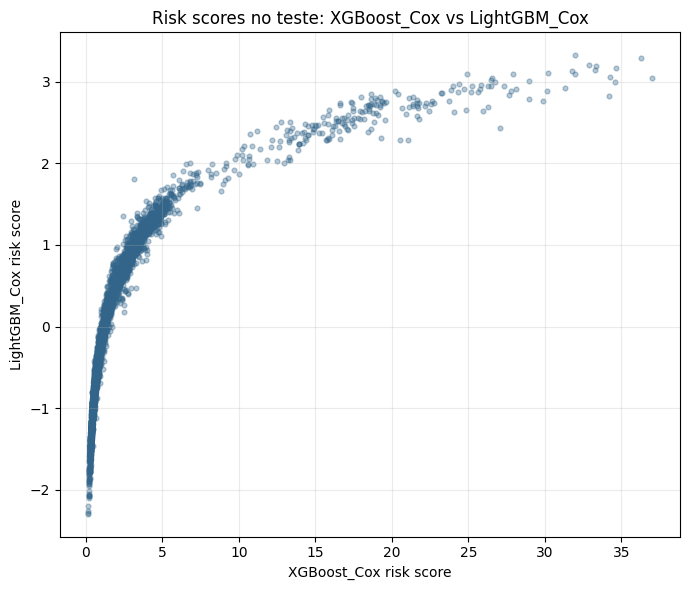

,model_pair,spearman_correlation,interpretation
0,LightGBM_Cox vs XGBoost_Cox,0.9938,correlação positiva moderada/alta; sugere coer...


In [16]:
if lightgbm_cox_available and "XGBoost_Cox" in fitted_models:
    xgboost_cox_risk_test = safe_1d(fitted_models["XGBoost_Cox"]["estimator"].predict(X_test_encoded))
    spearman_corr = pd.Series(lightgbm_cox_risk_test).corr(pd.Series(xgboost_cox_risk_test), method="spearman")

    if pd.isna(spearman_corr):
        interpretation = "correlação indisponível"
    elif spearman_corr >= 0.50:
        interpretation = "correlação positiva moderada/alta; sugere coerência entre modelos de risco"
    elif spearman_corr >= 0.20:
        interpretation = "correlação positiva baixa/moderada; sugere alguma coerência entre modelos de risco"
    elif spearman_corr <= -0.50:
        interpretation = "correlação negativa forte; pode indicar sinal invertido ou comportamento divergente"
    elif abs(spearman_corr) < 0.20:
        interpretation = "correlação próxima de zero; não invalida o modelo, mas deve ser discutida"
    else:
        interpretation = "correlação negativa fraca/moderada; revisar direção e coerência clínica"

    df_lightgbm_cox_comparison_with_xgboost = pd.DataFrame([{
        "model_pair": "LightGBM_Cox vs XGBoost_Cox",
        "spearman_correlation": float(spearman_corr),
        "interpretation": interpretation,
    }])

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(xgboost_cox_risk_test, lightgbm_cox_risk_test, s=12, alpha=0.35, color="#33658A")
    ax.set_title("Risk scores no teste: XGBoost_Cox vs LightGBM_Cox")
    ax.set_xlabel("XGBoost_Cox risk score")
    ax.set_ylabel("LightGBM_Cox risk score")
    ax.grid(axis="both", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lightgbm_cox_vs_xgboost_cox_risk_scores_2025.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    spearman_corr = np.nan
    df_lightgbm_cox_comparison_with_xgboost = pd.DataFrame([{
        "model_pair": "LightGBM_Cox vs XGBoost_Cox",
        "spearman_correlation": np.nan,
        "interpretation": "comparação indisponível porque um dos modelos não foi ajustado",
    }])

display(df_lightgbm_cox_comparison_with_xgboost.round(4))
df_lightgbm_cox_comparison_with_xgboost.to_csv(
    METRICS_DIR / "lightgbm_cox_comparison_with_xgboost_cox_2025.csv",
    index=False,
)


In [17]:
lightgbm_cox_sanity_checks = {
    "gradient_validation_passed": bool(df_lightgbm_cox_objective_validation.loc[0, "validation_passed"]),
    "direction_check_passed": bool(df_lightgbm_cox_direction_check.loc[0, "direction_check_passed"]),
    "generalization_gap": (
        None
        if pd.isna(df_lightgbm_cox_generalization_check.loc[0, "generalization_gap"])
        else float(df_lightgbm_cox_generalization_check.loc[0, "generalization_gap"])
    ),
    "overfitting_warning": bool(df_lightgbm_cox_generalization_check.loc[0, "overfitting_warning"]),
    "risk_group_monotonicity_passed": bool(risk_group_monotonicity_passed),
    "spearman_with_xgboost_cox": None if pd.isna(spearman_corr) else float(spearman_corr),
}

print("Resumo das checagens de sanidade do LightGBM_Cox:")
for check_name, check_value in lightgbm_cox_sanity_checks.items():
    print(f"- {check_name}: {check_value}")


Resumo das checagens de sanidade do LightGBM_Cox:
- gradient_validation_passed: True
- direction_check_passed: True
- generalization_gap: 0.014128274852490574
- overfitting_warning: False
- risk_group_monotonicity_passed: True
- spearman_with_xgboost_cox: 0.9938262405592747


## Fase 7 — Predições e probabilidades de sobrevivência

A tabela longa de predições guarda uma linha por paciente e por modelo. Para modelos com função de sobrevivência, são geradas probabilidades previstas em 12, 36 e 60 meses. Para modelos sem curva individual, essas colunas ficam como `NaN`. Para o `XGBoost_AFT`, a saída de `predict()` foi mantida como tempo em meses; não foi aplicado `np.exp()`.


In [18]:
all_model_predictions = pd.concat(prediction_frames, ignore_index=True)
prediction_columns = [
    "sample_index",
    "actual_time",
    "actual_event",
    "model_name",
    "risk_score",
    "predicted_time",
    "survival_probability_12m",
    "survival_probability_36m",
    "survival_probability_60m",
]
all_model_predictions = all_model_predictions[prediction_columns]
display(all_model_predictions.head(12))


,sample_index,actual_time,actual_event,model_name,risk_score,predicted_time,survival_probability_12m,survival_probability_36m,survival_probability_60m
0,0,5.0,1,Cox_PH,1.539436,39.0,0.786624,0.517914,0.386611
1,1,61.0,0,Cox_PH,0.861939,NaN,0.885241,0.715938,0.617138
2,2,8.0,1,Cox_PH,2.051002,22.0,0.670116,0.333742,0.204934
3,3,61.0,0,Cox_PH,-0.319018,NaN,0.963271,0.902504,0.862284
4,4,2.0,1,Cox_PH,3.762632,4.0,0.108949,0.002294,0.000154
5,5,45.0,1,Cox_PH,1.677810,33.0,0.759099,0.469734,0.335756
6,6,10.0,1,Cox_PH,2.106145,21.0,0.655080,0.313612,0.187322
7,7,3.0,1,Cox_PH,2.682289,11.0,0.471148,0.127057,0.050794
8,8,59.0,0,Cox_PH,0.623938,NaN,0.908393,0.768445,0.683564
9,9,16.0,1,Cox_PH,0.381589,NaN,0.927372,0.813262,0.741886


## Fase 8 — Comparação final dos modelos

A comparação final é separada em duas tabelas. A primeira ranqueia discriminação de risco, priorizando C-index IPCW e depois Mean Time AUC. A segunda compara apenas modelos com função de sobrevivência individual e prioriza menor IBS, porque Brier/IBS não são estruturalmente disponíveis para modelos que retornam apenas escore de risco ou tempo previsto.


In [19]:
df_metrics = pd.DataFrame(metrics_records)

discrimination_cols = ["model_name", "model_group", "model_family", "C_Index", "C_Index_IPCW", "AUC_12m", "AUC_36m", "AUC_60m", "Mean_Time_AUC"]
probability_cols = ["model_name", "model_group", "model_family", "Brier_12m", "Brier_36m", "Brier_60m", "IBS"]

df_discrimination = df_metrics[discrimination_cols].copy()
df_discrimination["rank_score"] = df_discrimination["C_Index_IPCW"].fillna(df_discrimination["Mean_Time_AUC"]).fillna(df_discrimination["C_Index"])
df_discrimination = df_discrimination.sort_values("rank_score", ascending=False).reset_index(drop=True)
df_discrimination.insert(0, "rank_discrimination", np.arange(1, len(df_discrimination) + 1))

df_probability = df_metrics[df_metrics["supports_survival_function"]].copy()
df_probability = df_probability[probability_cols].sort_values("IBS", ascending=True, na_position="last").reset_index(drop=True)
df_probability.insert(0, "rank_probability", np.arange(1, len(df_probability) + 1))

print("Tabela 1: Comparação por discriminação de risco")
display(df_discrimination.round(4))
print("Tabela 2: Comparação por predição probabilística/calibração")
display(df_probability.round(4))


Tabela 1: Comparação por discriminação de risco


,rank_discrimination,model_name,model_group,model_family,C_Index,C_Index_IPCW,AUC_12m,AUC_36m,AUC_60m,Mean_Time_AUC,rank_score
0,1,LightGBM_Cox,machine learning,risk_score,0.7484,0.7470,0.7980,0.8146,0.8142,0.8075,0.7470
1,2,Random_Survival_Forest,machine learning,survival_function,0.7471,0.7457,0.7998,0.8117,0.8115,0.8066,0.7457
2,3,XGBoost_Cox,machine learning,risk_score,0.7462,0.7448,0.7953,0.8122,0.8113,0.8048,0.7448
3,4,XGBoost_AFT,machine learning,predicted_time,0.7457,0.7440,0.7998,0.8082,0.8050,0.8041,0.7440
4,5,LightGBM,machine learning,predicted_time,0.7444,0.7431,0.7931,0.8143,0.8170,0.8058,0.7431
5,6,Gradient_Boosting_Survival,machine learning,survival_function,0.7345,0.7331,0.7819,0.7994,0.7979,0.7917,0.7331
6,7,LogLogistic_AFT,estatístico paramétrico,parametric_aft,0.7285,0.7269,0.7799,0.7886,0.7828,0.7839,0.7269
7,8,Cox_PH,estatístico semiparamétrico,survival_function,0.7278,0.7263,0.7759,0.7897,0.7853,0.7830,0.7263
8,9,Weibull_AFT,estatístico paramétrico,parametric_aft,0.7277,0.7262,0.7754,0.7897,0.7856,0.7829,0.7262
9,10,LogNormal_AFT,estatístico paramétrico,parametric_aft,0.7269,0.7252,0.7807,0.7850,0.7782,0.7820,0.7252


Tabela 2: Comparação por predição probabilística/calibração


,rank_probability,model_name,model_group,model_family,Brier_12m,Brier_36m,Brier_60m,IBS
0,1,Random_Survival_Forest,machine learning,survival_function,0.1394,0.1762,0.1746,0.1646
1,2,Gradient_Boosting_Survival,machine learning,survival_function,0.1437,0.1809,0.1809,0.1697
2,3,Cox_PH,estatístico semiparamétrico,survival_function,0.1441,0.1849,0.1860,0.1727
3,4,Weibull_AFT,estatístico paramétrico,parametric_aft,0.1446,0.1851,0.1863,0.1728
4,5,LogLogistic_AFT,estatístico paramétrico,parametric_aft,0.1435,0.1867,0.1884,0.1737
5,6,LogNormal_AFT,estatístico paramétrico,parametric_aft,0.1437,0.1888,0.1901,0.1751


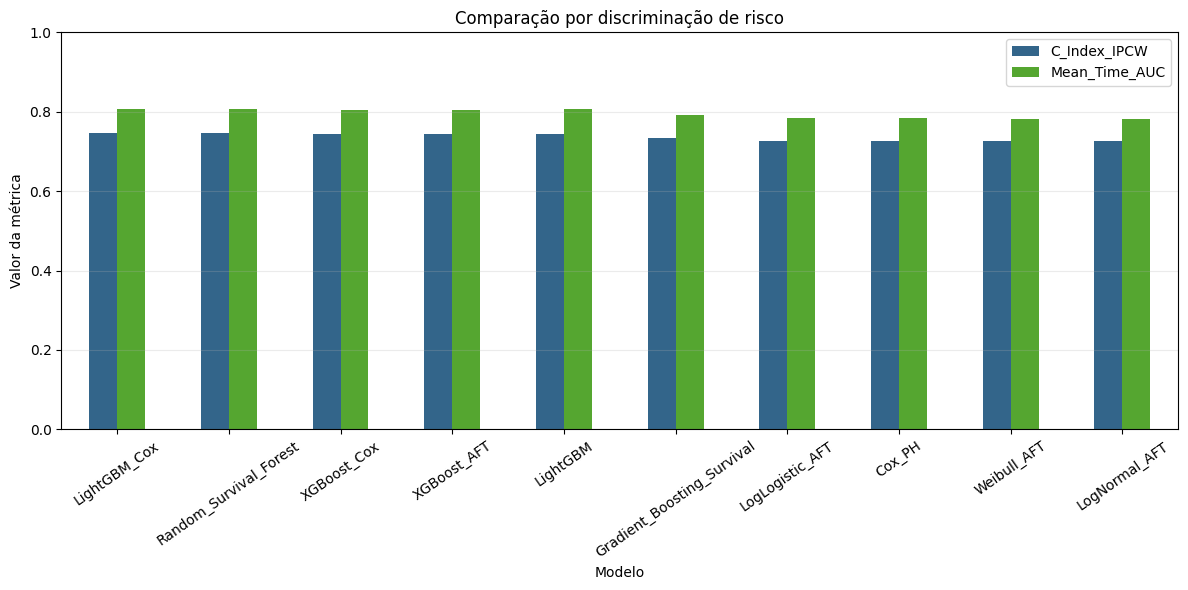

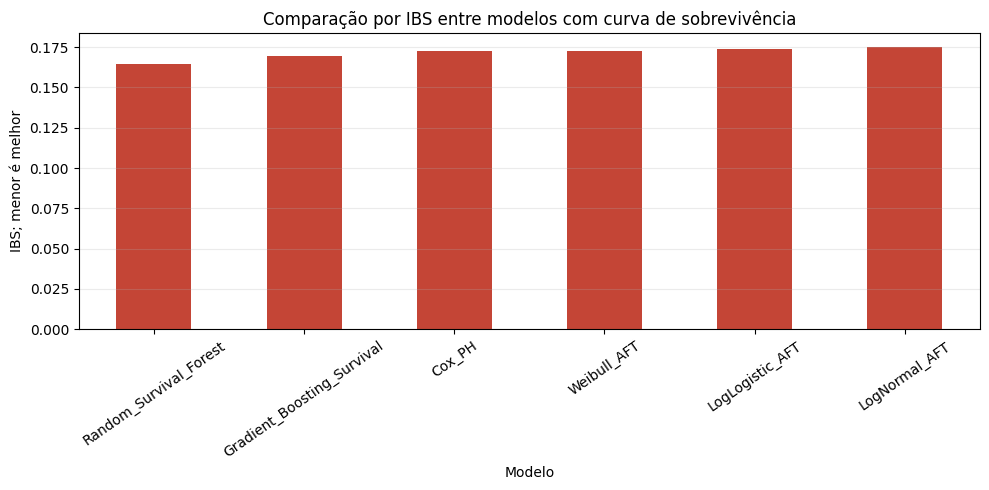

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = df_discrimination.set_index("model_name")[["C_Index_IPCW", "Mean_Time_AUC"]]
plot_df.plot(kind="bar", ax=ax, color=["#33658A", "#55A630"])
ax.set_title("Comparação por discriminação de risco")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor da métrica")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_discrimination.png", dpi=300, bbox_inches="tight")
plt.show()

if not df_probability.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    df_probability.set_index("model_name")[["IBS"]].plot(kind="bar", ax=ax, color="#C44536", legend=False)
    ax.set_title("Comparação por IBS entre modelos com curva de sobrevivência")
    ax.set_xlabel("Modelo")
    ax.set_ylabel("IBS; menor é melhor")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "model_comparison_probability.png", dpi=300, bbox_inches="tight")
    plt.show()


## Resultados para o artigo

Esta seção consolida as tabelas e figuras necessárias para a seção de Resultados do artigo de IC. As saídas usam exclusivamente os modelos já ajustados na divisão treino/teste definida anteriormente; não há seleção adicional de parâmetros nem alteração dos hiperparâmetros.


### Tabela 3 — Métricas dos modelos

A tabela final de métricas reúne discriminação, AUC temporal e métricas probabilísticas quando disponíveis. Brier Score e IBS exigem função de sobrevivência individual; por isso, modelos que retornam apenas escore de risco ou tempo previsto permanecem com `NaN` nessas colunas.


In [ ]:
article_metric_columns = [
    "Model_Name",
    "Model_Type",
    "C_Index",
    "C_Index_IPCW",
    "AUC_12m",
    "AUC_36m",
    "AUC_60m",
    "Mean_Time_AUC",
    "Brier_12m",
    "Brier_36m",
    "Brier_60m",
    "IBS",
]

article_table_3 = df_metrics.copy().rename(columns={
    "model_name": "Model_Name",
    "model_family": "Model_Type",
})

for column in article_metric_columns:
    if column not in article_table_3.columns:
        article_table_3[column] = np.nan

article_table_3 = (
    article_table_3[article_metric_columns]
    .sort_values(["C_Index_IPCW", "Mean_Time_AUC", "C_Index"], ascending=False, na_position="last")
    .reset_index(drop=True)
)

article_table_3.to_csv(METRICS_DIR / "article_table_3_model_metrics_2025.csv", index=False)

try:
    article_table_3.to_latex(
        METRICS_DIR / "article_table_3_model_metrics_2025.tex",
        index=False,
        float_format="%.4f",
        na_rep="--",
        caption="Comparação das métricas dos modelos de sobrevivência.",
        label="tab:model_metrics",
    )
except Exception:
    latex_table = article_table_3.to_string(index=False, na_rep="--")
    (METRICS_DIR / "article_table_3_model_metrics_2025.tex").write_text(latex_table, encoding="utf-8")

display(article_table_3.round(4))


### Figura 2 — Cinco variáveis mais influentes por modelo

As importâncias são extraídas de coeficientes absolutos, importâncias nativas do estimador ou ganho dos wrappers XGBoost/LightGBM. Antes do ranqueamento, as colunas one-hot são agregadas de volta ao nome conceitual da variável original.


In [ ]:
article_importance_models = [
    "Cox_PH",
    "Random_Survival_Forest",
    "Gradient_Boosting_Survival",
    "XGBoost_Cox",
    "XGBoost_AFT",
    "LightGBM_Cox",
]


def map_encoded_feature_to_original(feature_name):
    for original_name in sorted(schema_cols, key=len, reverse=True):
        if feature_name == original_name or feature_name.startswith(f"{original_name}_"):
            return original_name
    return feature_name


encoded_feature_groups = {
    original_name: [feature for feature in X_train_encoded.columns if map_encoded_feature_to_original(feature) == original_name]
    for original_name in schema_cols
}


def cindex_from_model_risk(model, X_eval, y_eval):
    risk = safe_1d(model.predict(X_eval))
    return concordance_index_censored(y_eval["event"], y_eval["time"], risk)[0]


def grouped_permutation_importance(model, X_eval, y_eval):
    baseline = cindex_from_model_risk(model, X_eval, y_eval)
    rng = np.random.default_rng(RANDOM_STATE)
    records = []

    for variable, columns in encoded_feature_groups.items():
        if not columns:
            continue
        X_permuted = X_eval.copy()
        permutation_index = rng.permutation(len(X_permuted))
        X_permuted.loc[:, columns] = X_permuted.iloc[permutation_index][columns].to_numpy()
        permuted_score = cindex_from_model_risk(model, X_permuted, y_eval)
        records.append({
            "variable": variable,
            "importance": max(float(baseline - permuted_score), 0.0),
        })

    return pd.DataFrame(records)


def model_importance_by_variable(model_name):
    if model_name not in fitted_models:
        return pd.DataFrame(columns=["variable", "importance"])

    model = fitted_models[model_name]["estimator"]
    importance_values = None

    try:
        coef_values = getattr(model, "coef_")
    except Exception:
        coef_values = None

    if coef_values is not None:
        importance_values = np.abs(safe_1d(coef_values))
    else:
        try:
            feature_importances = getattr(model, "feature_importances_")
            importance_values = safe_1d(feature_importances)
        except Exception:
            importance_values = None

    if importance_values is None or len(importance_values) != len(X_train_encoded.columns):
        return grouped_permutation_importance(model, X_test_encoded, y_test_surv)

    importance_df = pd.DataFrame({
        "encoded_feature": X_train_encoded.columns,
        "variable": [map_encoded_feature_to_original(feature) for feature in X_train_encoded.columns],
        "importance": importance_values,
    })

    return (
        importance_df
        .groupby("variable", as_index=False)["importance"]
        .sum()
    )


top5_importance_frames = []
for model_name in article_importance_models:
    importance_by_variable = model_importance_by_variable(model_name)
    if importance_by_variable.empty:
        continue

    top5 = (
        importance_by_variable
        .sort_values("importance", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    top5.insert(0, "model_name", model_name)
    top5["rank"] = np.arange(1, len(top5) + 1)
    top5_importance_frames.append(top5[["model_name", "variable", "importance", "rank"]])

article_top5_feature_importance = (
    pd.concat(top5_importance_frames, ignore_index=True)
    if top5_importance_frames
    else pd.DataFrame(columns=["model_name", "variable", "importance", "rank"])
)

article_top5_feature_importance.to_csv(
    METRICS_DIR / "article_top5_feature_importance_by_model_2025.csv",
    index=False,
)

display(article_top5_feature_importance.round(6))


In [ ]:
if not article_top5_feature_importance.empty:
    plot_importance = article_top5_feature_importance.copy()
    plot_importance["importance_scaled"] = plot_importance.groupby("model_name")["importance"].transform(
        lambda values: values / values.max() if values.max() > 0 else values
    )
    models_to_plot = plot_importance["model_name"].drop_duplicates().tolist()
    ncols = 2
    nrows = int(np.ceil(len(models_to_plot) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13, 3.4 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)

    for ax, model_name in zip(axes, models_to_plot):
        subset = plot_importance[plot_importance["model_name"] == model_name].sort_values("rank", ascending=False)
        ax.barh(subset["variable"], subset["importance_scaled"], color="#33658A")
        ax.set_title(model_name)
        ax.set_xlabel("Importância relativa")
        ax.set_xlim(0, 1.05)
        ax.grid(axis="x", alpha=0.25)

    for ax in axes[len(models_to_plot):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "article_fig2_top5_feature_importance_by_model_2025.png", dpi=300, bbox_inches="tight")
    plt.show()


### Figura 3 — Cox versus melhor modelo de Machine Learning com curva de sobrevivência

A comparação usa a curva média prevista no teste pelo Cox e pelo melhor modelo de Machine Learning que fornece função de sobrevivência individual. A curva Kaplan-Meier observada no teste é incluída como referência empírica.


In [ ]:
def mean_survival_curve(model_name, times):
    model = fitted_models[model_name]["estimator"]
    survival_matrix = survival_matrix_from_model(model, X_test_encoded, times)
    return np.nanmean(survival_matrix, axis=0)


curve_times = np.arange(1, 61, dtype=float)
cox_model_name = "Cox_PH"
ml_survival_candidates = [
    name for name, entry in fitted_models.items()
    if entry["group"] == "machine learning" and entry["supports_survival_function"]
]

candidate_rank = df_discrimination[df_discrimination["model_name"].isin(ml_survival_candidates)].copy()
best_ml_survival_model = (
    candidate_rank.sort_values("rank_score", ascending=False).iloc[0]["model_name"]
    if not candidate_rank.empty
    else None
)

kmf_test = KaplanMeierFitter()
kmf_test.fit(y_test_surv["time"], event_observed=y_test_surv["event"].astype(int), label="Kaplan-Meier observado")

cox_mean_survival = mean_survival_curve(cox_model_name, curve_times) if cox_model_name in fitted_models else np.full_like(curve_times, np.nan, dtype=float)
best_ml_mean_survival = (
    mean_survival_curve(best_ml_survival_model, curve_times)
    if best_ml_survival_model is not None
    else np.full_like(curve_times, np.nan, dtype=float)
)
observed_km_survival = np.array([float(kmf_test.predict(time)) for time in curve_times])

article_fig3_survival_curves = pd.DataFrame({
    "time_months": curve_times.astype(int),
    "cox_predicted_survival": cox_mean_survival,
    "best_ml_model": best_ml_survival_model,
    "best_ml_predicted_survival": best_ml_mean_survival,
    "observed_km_survival": observed_km_survival,
})
article_fig3_survival_curves.to_csv(
    METRICS_DIR / "article_fig3_survival_curves_2025.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(curve_times, observed_km_survival, label="Kaplan-Meier observado", color="#222222", linewidth=2.2)
ax.plot(curve_times, cox_mean_survival, label="Cox_PH previsto", color="#33658A", linewidth=2)
if best_ml_survival_model is not None:
    ax.plot(curve_times, best_ml_mean_survival, label=f"{best_ml_survival_model} previsto", color="#55A630", linewidth=2)
ax.set_title("Curva média prevista: Cox versus melhor modelo de ML")
ax.set_xlabel("Tempo desde o diagnóstico (meses)")
ax.set_ylabel("Sobrevivência")
ax.set_ylim(0, 1)
ax.grid(axis="both", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "article_fig3_cox_vs_best_ml_survival_curve_2025.png", dpi=300, bbox_inches="tight")
plt.show()

print("Melhor modelo de ML com função de sobrevivência:", best_ml_survival_model)


### Kaplan-Meier por grupos de risco do melhor modelo

O melhor modelo geral é selecionado pela ordenação de discriminação. Seus escores de risco no teste são divididos em tercis para verificar se os grupos de maior risco apresentam maior taxa de eventos e menor sobrevivência observada.


In [ ]:
best_article_model_name = df_discrimination.sort_values("rank_score", ascending=False).iloc[0]["model_name"]


def get_article_risk_scores(model_name):
    if (
        model_name == "LightGBM_Cox"
        and "lightgbm_cox_risk_score_corrected" in globals()
        and len(lightgbm_cox_risk_score_corrected) == len(y_test_surv)
    ):
        return safe_1d(lightgbm_cox_risk_score_corrected)

    model_predictions = all_model_predictions[all_model_predictions["model_name"] == model_name]
    if not model_predictions.empty:
        return safe_1d(model_predictions.sort_values("sample_index")["risk_score"])

    return safe_1d(fitted_models[model_name]["estimator"].predict(X_test_encoded))


best_model_risk_scores = get_article_risk_scores(best_article_model_name)
article_risk_group = pd.qcut(
    pd.Series(best_model_risk_scores).rank(method="first"),
    q=3,
    labels=risk_group_labels,
)

article_risk_group_records = []
kmf_group = KaplanMeierFitter()

for group_name in risk_group_labels:
    group_mask = article_risk_group.to_numpy() == group_name
    group_time = y_test_surv["time"][group_mask]
    group_event = y_test_surv["event"][group_mask].astype(int)
    kmf_group.fit(group_time, event_observed=group_event, label=group_name)

    article_risk_group_records.append({
        "risk_group": group_name,
        "n": int(group_mask.sum()),
        "event_rate": float(np.mean(group_event)),
        "median_observed_time": float(np.median(group_time)),
        "survival_12m_km": float(kmf_group.predict(12.0)),
        "survival_36m_km": float(kmf_group.predict(36.0)),
        "survival_60m_km": float(kmf_group.predict(60.0)),
    })

article_risk_group_summary = pd.DataFrame(article_risk_group_records)
article_risk_group_event_monotonic = bool(np.all(np.diff(article_risk_group_summary["event_rate"]) >= -1e-8))
article_risk_group_survival_monotonic = bool(all(
    np.all(np.diff(article_risk_group_summary[column]) <= 1e-8)
    for column in ["survival_12m_km", "survival_36m_km", "survival_60m_km"]
))
article_risk_group_monotonicity_passed = bool(article_risk_group_event_monotonic and article_risk_group_survival_monotonic)
article_risk_group_summary["monotonicity_check"] = article_risk_group_monotonicity_passed
article_risk_group_summary.insert(0, "model_name", best_article_model_name)

article_risk_group_summary.to_csv(
    METRICS_DIR / "article_risk_group_summary_best_model_2025.csv",
    index=False,
)

if not article_risk_group_monotonicity_passed:
    print("Atenção: a ordenação por grupos de risco do melhor modelo não foi plenamente confirmada.")

display(article_risk_group_summary.round(4))


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
kmf_group = KaplanMeierFitter()

for group_name in risk_group_labels:
    group_mask = article_risk_group.to_numpy() == group_name
    kmf_group.fit(
        y_test_surv["time"][group_mask],
        event_observed=y_test_surv["event"][group_mask].astype(int),
        label=group_name,
    )
    kmf_group.plot_survival_function(ax=ax, ci_show=False)

ax.set_title(f"Kaplan-Meier por tercis de risco: {best_article_model_name}")
ax.set_xlabel("Tempo desde o diagnóstico (meses)")
ax.set_ylabel("Sobrevivência estimada")
ax.set_ylim(0, 1)
ax.grid(axis="both", alpha=0.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "article_km_by_risk_group_best_model_2025.png", dpi=300, bbox_inches="tight")
plt.show()


### Calibração em 12, 36 e 60 meses

Para modelos com função de sobrevivência individual, o risco previsto em cada horizonte é calculado como `1 - S(t)`. Os pacientes são agrupados em quintis de risco previsto, e o risco observado em cada grupo é estimado por Kaplan-Meier.


In [ ]:
calibration_horizons = [12, 36, 60]
calibration_groups = 5
calibration_records = []

survival_model_names = [
    name for name, entry in fitted_models.items()
    if entry["supports_survival_function"]
]

for model_name in survival_model_names:
    model = fitted_models[model_name]["estimator"]

    for horizon in calibration_horizons:
        predicted_survival = survival_matrix_from_model(model, X_test_encoded, np.array([float(horizon)]))[:, 0]
        predicted_risk = np.clip(1.0 - predicted_survival, 0.0, 1.0)
        calibration_group = pd.qcut(
            pd.Series(predicted_risk).rank(method="first"),
            q=calibration_groups,
            labels=False,
        ) + 1

        for group_id in sorted(calibration_group.unique()):
            group_mask = calibration_group.to_numpy() == group_id
            kmf_calibration = KaplanMeierFitter()
            kmf_calibration.fit(
                y_test_surv["time"][group_mask],
                event_observed=y_test_surv["event"][group_mask].astype(int),
            )
            observed_risk = 1.0 - float(kmf_calibration.predict(float(horizon)))

            calibration_records.append({
                "model_name": model_name,
                "horizon_months": horizon,
                "calibration_group": int(group_id),
                "n": int(group_mask.sum()),
                "mean_predicted_risk": float(np.mean(predicted_risk[group_mask])),
                "observed_risk_km": observed_risk,
            })

article_calibration_by_horizon = pd.DataFrame(calibration_records)
article_calibration_by_horizon.to_csv(
    METRICS_DIR / "article_calibration_by_horizon_2025.csv",
    index=False,
)

display(article_calibration_by_horizon.head(15).round(4))


In [ ]:
for horizon in calibration_horizons:
    horizon_df = article_calibration_by_horizon[article_calibration_by_horizon["horizon_months"] == horizon]

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0, 1], [0, 1], linestyle="--", color="#222222", linewidth=1.4, label="Calibração perfeita")

    for model_name, model_df in horizon_df.groupby("model_name"):
        model_df = model_df.sort_values("mean_predicted_risk")
        ax.plot(
            model_df["mean_predicted_risk"],
            model_df["observed_risk_km"],
            marker="o",
            linewidth=1.6,
            label=model_name,
        )

    ax.set_title(f"Calibração em {horizon} meses")
    ax.set_xlabel("Risco previsto médio")
    ax.set_ylabel("Risco observado por Kaplan-Meier")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(axis="both", alpha=0.25)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"article_calibration_{horizon}m_2025.png", dpi=300, bbox_inches="tight")
    plt.show()


### Sanidade do LightGBM_Cox

Como o `LightGBM_Cox` usa objetivo customizado, a tabela abaixo consolida as checagens matemáticas, de direção do risco, generalização e coerência com o `XGBoost_Cox`.


In [ ]:
if "LightGBM_Cox" in fitted_models:
    article_lightgbm_cox_sanity_checks = pd.DataFrame([{
        "gradient_validation_passed": bool(df_lightgbm_cox_objective_validation.loc[0, "validation_passed"]),
        "direction_check_passed": bool(df_lightgbm_cox_direction_check.loc[0, "direction_check_passed"]),
        "cindex_train": float(df_lightgbm_cox_generalization_check.loc[0, "cindex_train"]),
        "cindex_test": float(df_lightgbm_cox_generalization_check.loc[0, "cindex_test"]),
        "generalization_gap": float(df_lightgbm_cox_generalization_check.loc[0, "generalization_gap"]),
        "overfitting_warning": bool(df_lightgbm_cox_generalization_check.loc[0, "overfitting_warning"]),
        "risk_group_monotonicity_passed": bool(risk_group_monotonicity_passed),
        "spearman_with_xgboost_cox": (
            np.nan
            if df_lightgbm_cox_comparison_with_xgboost["spearman_correlation"].isna().all()
            else float(df_lightgbm_cox_comparison_with_xgboost.loc[0, "spearman_correlation"])
        ),
    }])
else:
    article_lightgbm_cox_sanity_checks = pd.DataFrame([{
        "gradient_validation_passed": False,
        "direction_check_passed": False,
        "cindex_train": np.nan,
        "cindex_test": np.nan,
        "generalization_gap": np.nan,
        "overfitting_warning": False,
        "risk_group_monotonicity_passed": False,
        "spearman_with_xgboost_cox": np.nan,
    }])

article_lightgbm_cox_sanity_checks.to_csv(
    METRICS_DIR / "article_lightgbm_cox_sanity_checks_2025.csv",
    index=False,
)

display(article_lightgbm_cox_sanity_checks.round(4))


In [ ]:
article_output_files = {
    "Tabela 3": [
        str(METRICS_DIR / "article_table_3_model_metrics_2025.csv"),
        str(METRICS_DIR / "article_table_3_model_metrics_2025.tex"),
    ],
    "Figura 2": [
        str(FIGURES_DIR / "article_fig2_top5_feature_importance_by_model_2025.png"),
        str(METRICS_DIR / "article_top5_feature_importance_by_model_2025.csv"),
    ],
    "Figura 3": [
        str(FIGURES_DIR / "article_fig3_cox_vs_best_ml_survival_curve_2025.png"),
        str(METRICS_DIR / "article_fig3_survival_curves_2025.csv"),
    ],
    "KM por grupos de risco": [
        str(FIGURES_DIR / "article_km_by_risk_group_best_model_2025.png"),
        str(METRICS_DIR / "article_risk_group_summary_best_model_2025.csv"),
    ],
    "Calibração 12/36/60 meses": [
        str(FIGURES_DIR / "article_calibration_12m_2025.png"),
        str(FIGURES_DIR / "article_calibration_36m_2025.png"),
        str(FIGURES_DIR / "article_calibration_60m_2025.png"),
        str(METRICS_DIR / "article_calibration_by_horizon_2025.csv"),
    ],
    "Tabela de sanidade LightGBM_Cox": [
        str(METRICS_DIR / "article_lightgbm_cox_sanity_checks_2025.csv"),
    ],
}


## Fase 9 — Salvamento dos resultados

São salvos os arquivos finais de métricas, predições, parâmetros fixos e artefatos. O pré-processador é sempre salvo. Os modelos ajustados também são salvos quando o objeto é serializável no ambiente atual; caso algum backend tenha restrição de compatibilidade, a falha é registrada sem interromper o salvamento dos demais resultados.


In [21]:
df_discrimination.to_csv(METRICS_DIR / "model_comparison_discrimination.csv", index=False)
df_probability.to_csv(METRICS_DIR / "model_comparison_probability.csv", index=False)
all_model_predictions.to_csv(PREDS_DIR / "all_model_predictions.csv", index=False)

def to_json_safe(obj):
    if isinstance(obj, dict):
        return {str(key): to_json_safe(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_json_safe(value) for value in obj]
    if isinstance(obj, np.ndarray):
        return [to_json_safe(value) for value in obj.tolist()]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if callable(obj):
        return getattr(obj, "__name__", str(obj))
    return obj

schema_payload = {
    "variable_schema": variable_schema,
    "encoded_feature_names": feature_names_encoded,
    "ordinal_categories": {"ECGRUP": ordinal_categories[0], "ESCOLARI": ordinal_categories[1]},
    "binary_mapping": getattr(preprocessor.named_transformers_["binary"], "category_maps_", {}),
}
lightgbm_cox_sanity_checks_payload = globals().get("lightgbm_cox_sanity_checks", {})
article_outputs_payload = globals().get("article_output_files", {})

summary_payload = {
    "generated_at": datetime.now().isoformat(),
    "discrimination_ranking": df_discrimination.to_dict(orient="records"),
    "probability_ranking": df_probability.to_dict(orient="records"),
    "training_failures": training_failures,
    "lightgbm_cox_sanity_checks": lightgbm_cox_sanity_checks_payload,
    "article_outputs": article_outputs_payload,
}

params_payload = {
    "generated_at": datetime.now().isoformat(),
    "random_state": RANDOM_STATE,
    "clinical_prediction_horizons_months": CLINICAL_TIMES.astype(int).tolist(),
    "fixed_model_parameters": fixed_model_parameters,
    "fitted_model_parameters": fitted_params_summary,
    "training_failures": training_failures,
    "lightgbm_cox_sanity_checks": lightgbm_cox_sanity_checks_payload,
    "methodological_notes": {
        "parameter_selection": "Não realizado nesta versão.",
        "validation": "Treino para ajuste; teste somente para avaliação final.",
        "xgboost_aft_prediction_scale": "Predição mantida em meses; np.exp() não aplicado.",
        "cox_final": "O Cox estatístico completo é tratado separadamente no notebook Cox.ipynb.",
    },
}

with open(RESULTS_DIR / "model_comparison_summary_2025.json", "w", encoding="utf-8") as file:
    json.dump(to_json_safe(summary_payload), file, indent=2, ensure_ascii=False)

with open(PARAMS_DIR / "fixed_model_parameters.json", "w", encoding="utf-8") as file:
    json.dump(to_json_safe(params_payload), file, indent=2, ensure_ascii=False)
with open(ARTIFACTS_DIR / "column_schema.json", "w", encoding="utf-8") as file:
    json.dump(to_json_safe(schema_payload), file, indent=2, ensure_ascii=False)

joblib.dump(preprocessor, ARTIFACTS_DIR / "preprocessor.joblib")

model_save_status = {}
for model_name, entry in fitted_models.items():
    model_path = FITTED_MODELS_DIR / f"{model_name}.joblib"
    try:
        joblib.dump(entry["estimator"], model_path)
        model_save_status[model_name] = "saved"
    except Exception as exc:
        model_save_status[model_name] = f"not_saved: {exc}"

with open(ARTIFACTS_DIR / "fitted_model_save_status.json", "w", encoding="utf-8") as file:
    json.dump(to_json_safe(model_save_status), file, indent=2, ensure_ascii=False)

print("Arquivos salvos:")
print("-", METRICS_DIR / "model_comparison_discrimination.csv")
print("-", METRICS_DIR / "model_comparison_probability.csv")
print("-", PREDS_DIR / "all_model_predictions.csv")
print("-", RESULTS_DIR / "model_comparison_summary_2025.json")
print("-", PARAMS_DIR / "fixed_model_parameters.json")
print("-", ARTIFACTS_DIR / "preprocessor.joblib")
print("-", ARTIFACTS_DIR / "column_schema.json")
print("-", FITTED_MODELS_DIR)


Arquivos salvos:
- results\metrics\model_comparison_discrimination.csv
- results\metrics\model_comparison_probability.csv
- results\predictions\all_model_predictions.csv
- results\model_comparison_summary_2025.json
- results\params\fixed_model_parameters.json
- results\artifacts\preprocessor.joblib
- results\artifacts\column_schema.json
- results\artifacts\fitted_models


In [ ]:
article_outputs_to_print = globals().get("article_output_files", {})
print("Arquivos gerados para o artigo:")
for placeholder, paths in article_outputs_to_print.items():
    print(f"- {placeholder}")
    for path in paths:
        print(f"  - {path}")


## Fase 10 — Conclusão metodológica

Este notebook usa parâmetros fixos e não inclui modelos de margem máxima. A comparação usa a divisão treino/teste já definida pelo pré-processamento, com codificação ajustada somente no treino. As métricas de discriminação permitem comparar todos os modelos por ordenação de risco; as métricas probabilísticas são restritas aos modelos que produzem função de sobrevivência individual.

As limitações principais são: `LightGBM` sem Cox é apenas um baseline de tempo observado e não modela censura diretamente; modelos de risk score não fornecem Brier/IBS sem uma etapa adicional de calibração de sobrevivência; e o Cox aqui serve como baseline interno da matriz codificada, enquanto a análise estatística final deve ser feita a partir do notebook `Cox.ipynb`.

O `LightGBM_Cox` deve ser interpretado como modelo customizado experimental. Seus resultados só devem ser considerados confiáveis se as checagens de gradiente, direção do risco e grupos de risco forem aprovadas.
